In [1]:
from google.colab import files

uploaded = files.upload()

Saving GSE24368_series_matrix.txt.gz to GSE24368_series_matrix.txt.gz


In [2]:
import gzip

file_path = "/content/GSE24368_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    for i in range(5):
        print(f.readline().strip())

!Series_title	"Distinct Early Molecular Responses to Mutations Causing vLINCL and JNCL Presage ATP Synthase Subunit c Accumulation in Cerebellar Cells"
!Series_geo_accession	"GSE24368"
!Series_status	"Public on Feb 01 2011"
!Series_submission_date	"Sep 25 2010"
!Series_last_update_date	"Feb 11 2019"


In [3]:
import gzip

file_path = "/content/GSE24368_series_matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    for i in range(30):
        print(f.readline().strip())

!Series_title	"Distinct Early Molecular Responses to Mutations Causing vLINCL and JNCL Presage ATP Synthase Subunit c Accumulation in Cerebellar Cells"
!Series_geo_accession	"GSE24368"
!Series_status	"Public on Feb 01 2011"
!Series_submission_date	"Sep 25 2010"
!Series_last_update_date	"Feb 11 2019"
!Series_pubmed_id	"21359198"
!Series_pubmed_id	"25878248"
!Series_summary	"Variant late-infantile (vLINCL) and juvenile neuronal ceroid lipofuscinosis (JNCL) share clinical and pathological features, including lysosomal accumulation of mitochondrial ATP synthase subunit c, but the unrelated CLN6 and CLN3 genes may initiate disease via similar or distinct cellular processes. To gain insight into the NCL pathways, we established murine wild-type and vLINCL CbCln6nclf cerebellar cells and compared them to wild-type and JNCL CbCln3∆ex7/8 cerebellar cells. CbCln6nclf/nclf cells and CbCln3∆ex7/8/∆ex7/8 cells both displayed abnormally elongated mitochondria and reduced cellular ATP levels and, as 

In [4]:
import pandas as pd

file_path = "/content/GSE24368_series_matrix.txt.gz"

data = pd.read_csv(
    file_path,
    sep="\t",
    compression="gzip",
    comment="!",
)

print(data.shape)
print(data.head())
print(data.columns.tolist())

(45101, 13)
         ID_REF  GSM600916  GSM600917  GSM600918  GSM600919  GSM600920  \
0    1415670_at  11.971118  11.999707  12.093801  12.276464  12.964543   
1    1415671_at  12.893432  12.963062  12.810834  13.199224  13.024017   
2    1415672_at  12.398892  12.444844  12.315379  12.876685  12.503927   
3    1415673_at  13.322577  12.794791  12.750317  13.327787  12.849785   
4  1415674_a_at  10.682405  10.649087  10.560536  10.943247  10.675098   

   GSM600921  GSM600922  GSM600923  GSM600924  GSM600925  GSM600926  GSM600927  
0  12.553220  12.549947  12.588129  12.448738  12.211813  12.849543  12.411440  
1  13.884305  13.881138  13.188064  13.197100  12.836586  12.102030  13.314020  
2  12.862780  12.858537  12.349039  12.265414  12.572177  12.361067  12.724470  
3  12.193408  12.190461  13.686139  13.428093  12.767598  12.655554  12.463431  
4  10.893789  10.889789  10.779307  10.635566  10.881521  11.095914  10.713052  
['ID_REF', 'GSM600916', 'GSM600917', 'GSM600918', 'GSM600

In [5]:
print("Shape:", data.shape)

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isna().sum().sum())

print("\nDuplicate probe IDs:")
print(data["ID_REF"].duplicated().sum())

print("\nUnique probe IDs:")
print(data["ID_REF"].nunique())

Shape: (45101, 13)

Data types:
ID_REF        object
GSM600916    float64
GSM600917    float64
GSM600918    float64
GSM600919    float64
GSM600920    float64
GSM600921    float64
GSM600922    float64
GSM600923    float64
GSM600924    float64
GSM600925    float64
GSM600926    float64
GSM600927    float64
dtype: object

Missing values:
0

Duplicate probe IDs:
0

Unique probe IDs:
45101


In [6]:
sample_groups = {
    "GSM600916": "Cln3_WT",
    "GSM600917": "Cln3_WT",
    "GSM600918": "Cln3_WT",

    "GSM600919": "Cln3_Mutant",
    "GSM600920": "Cln3_Mutant",
    "GSM600921": "Cln3_Mutant",

    "GSM600922": "Cln6_WT",
    "GSM600923": "Cln6_WT",
    "GSM600924": "Cln6_WT",

    "GSM600925": "Cln6_Mutant",
    "GSM600926": "Cln6_Mutant",
    "GSM600927": "Cln6_Mutant"
}

for sample, group in sample_groups.items():
    print(sample, "→", group)

GSM600916 → Cln3_WT
GSM600917 → Cln3_WT
GSM600918 → Cln3_WT
GSM600919 → Cln3_Mutant
GSM600920 → Cln3_Mutant
GSM600921 → Cln3_Mutant
GSM600922 → Cln6_WT
GSM600923 → Cln6_WT
GSM600924 → Cln6_WT
GSM600925 → Cln6_Mutant
GSM600926 → Cln6_Mutant
GSM600927 → Cln6_Mutant


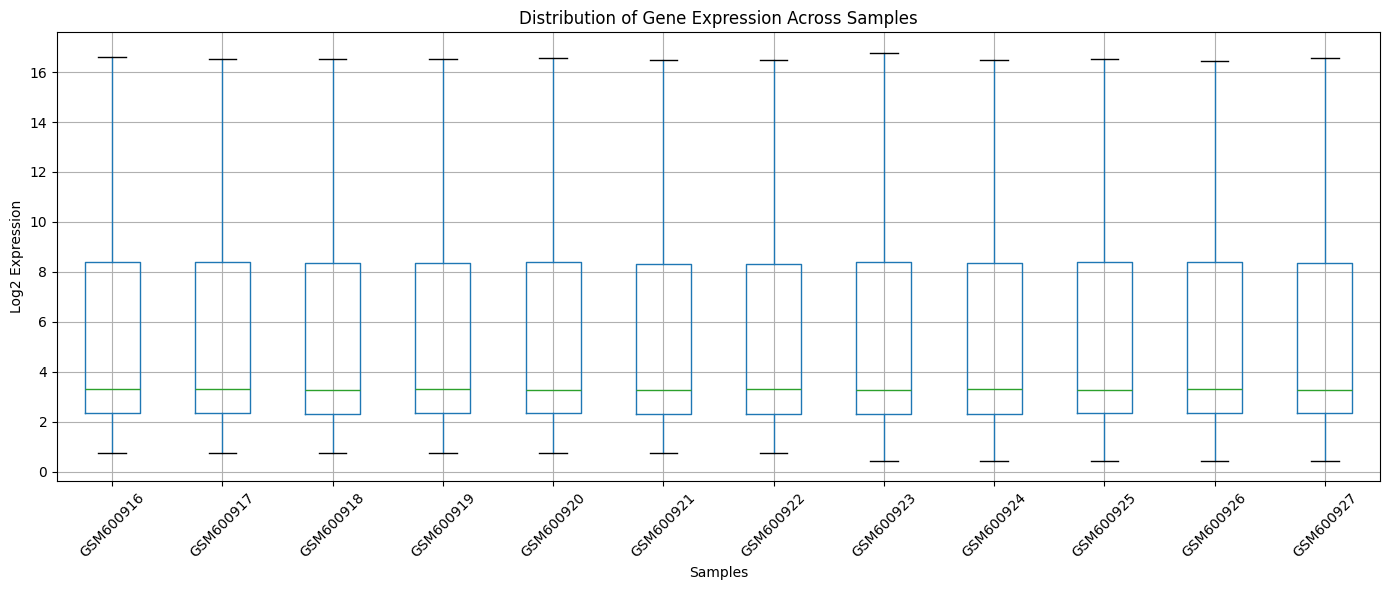

In [7]:
import matplotlib.pyplot as plt

expression_data = data.drop(columns="ID_REF")

plt.figure(figsize=(14, 6))

expression_data.boxplot()

plt.title("Distribution of Gene Expression Across Samples")
plt.xlabel("Samples")
plt.ylabel("Log2 Expression")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
expression_data = data.drop(columns="ID_REF")

summary = expression_data.describe().T[
    ["min", "25%", "50%", "75%", "max", "mean", "std"]
]

summary

,min,25%,50%,75%,max,mean,std
GSM600916,0.754118,2.367488,3.306169,8.381367,16.602802,5.350941,3.605441
GSM600917,0.756099,2.368213,3.299597,8.382024,16.533903,5.341163,3.606981
GSM600918,0.743208,2.323949,3.254853,8.370878,16.509879,5.326773,3.625582
GSM600919,0.753335,2.359178,3.296536,8.346550,16.533085,5.333715,3.597342
GSM600920,0.747179,2.346777,3.280753,8.402151,16.562664,5.344527,3.616272
GSM600921,0.742858,2.329760,3.292216,8.333607,16.475372,5.317928,3.613454
GSM600922,0.742398,2.329034,3.292932,8.332504,16.472067,5.316596,3.612657
GSM600923,0.443868,2.319393,3.259935,8.404194,16.773126,5.334044,3.630757
GSM600924,0.444596,2.318603,3.296422,8.368287,16.492042,5.339295,3.620324
GSM600925,0.449033,2.350566,3.276987,8.406153,16.511883,5.335570,3.619599


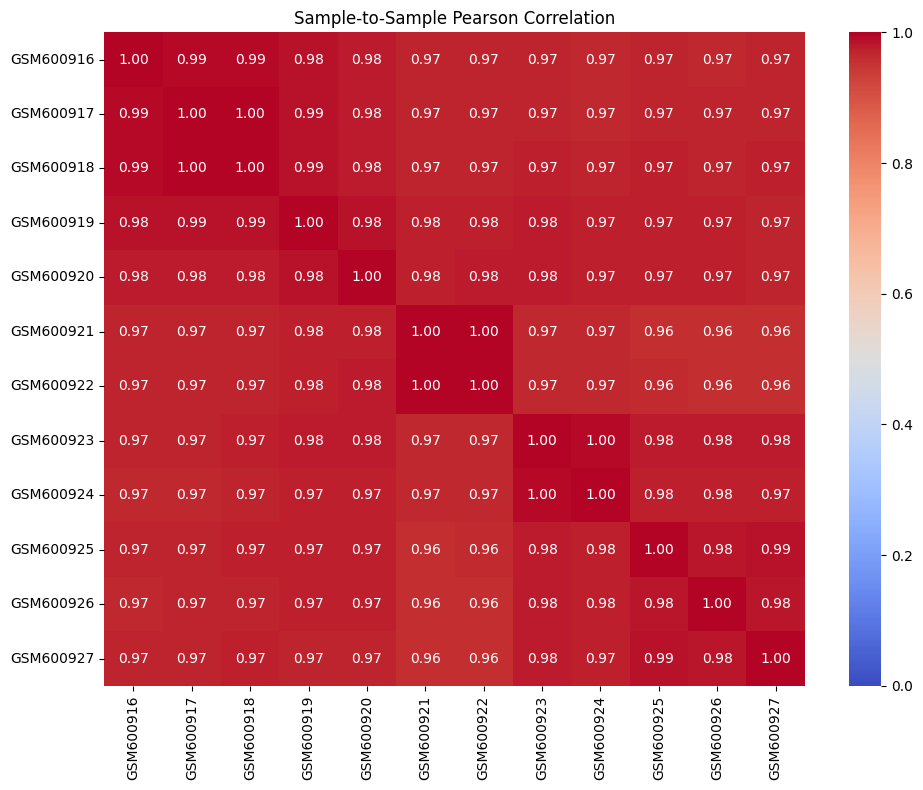

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = expression_data.corr(method="pearson")

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Sample-to-Sample Pearson Correlation")
plt.tight_layout()
plt.show()

In [10]:
correlation_matrix.round(3)

,GSM600916,GSM600917,GSM600918,GSM600919,GSM600920,GSM600921,GSM600922,GSM600923,GSM600924,GSM600925,GSM600926,GSM600927
GSM600916,1.000,0.993,0.994,0.985,0.980,0.971,0.971,0.970,0.967,0.971,0.968,0.971
GSM600917,0.993,1.000,0.997,0.987,0.980,0.972,0.972,0.972,0.968,0.973,0.969,0.971
GSM600918,0.994,0.997,1.000,0.986,0.980,0.971,0.971,0.973,0.969,0.973,0.970,0.973
GSM600919,0.985,0.987,0.986,1.000,0.985,0.975,0.976,0.978,0.975,0.975,0.974,0.971
GSM600920,0.980,0.980,0.980,0.985,1.000,0.976,0.977,0.977,0.974,0.975,0.973,0.971
GSM600921,0.971,0.972,0.971,0.975,0.976,1.000,1.000,0.965,0.965,0.961,0.960,0.957
GSM600922,0.971,0.972,0.971,0.976,0.977,1.000,1.000,0.966,0.966,0.961,0.960,0.958
GSM600923,0.970,0.972,0.973,0.978,0.977,0.965,0.966,1.000,0.995,0.980,0.978,0.978
GSM600924,0.967,0.968,0.969,0.975,0.974,0.965,0.966,0.995,1.000,0.975,0.976,0.974
GSM600925,0.971,0.973,0.973,0.975,0.975,0.961,0.961,0.980,0.975,1.000,0.984,0.988


In [11]:
from google.colab import files

uploaded = files.upload()

Saving GPL1261-56135.txt to GPL1261-56135.txt


In [12]:
import os

for file in os.listdir("/content"):
    if "GPL1261" in file:
        print(file)

GPL1261-56135.txt


In [13]:
file_path = "/content/GPL1261-56135.txt"

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(20):
        print(f.readline().rstrip())

#ID = Affymetrix Probe Set ID
#GB_ACC = GenBank Accession Number
#SPOT_ID = identifies controls
#Species Scientific Name = The genus and species of the organism represented by the probe set.
#Annotation Date = The date that the annotations for this probe array were last updated. It will generally be earlier than the date when the annotations were posted on the Affymetrix web site.
#Sequence Type =
#Sequence Source = The database from which the sequence used to design this probe set was taken.
#Target Description =
#Representative Public ID = The accession number of a representative sequence. Note that for consensus-based probe sets, the representative sequence is only one of several sequences (sequence sub-clusters) used to build the consensus sequence and it is not directly used to derive the probe sequences. The representative sequence is chosen during array design as a sequence that is best associated with the transcribed region being interrogated by the probe set. Refer to the "Seq

In [14]:
annotation_path = "/content/GPL1261-56135.txt"

annotation = pd.read_csv(
    annotation_path,
    sep="\t",
    comment="#",
    dtype=str
)

print("Annotation shape:", annotation.shape)

print("\nColumns:")
print(annotation.columns.tolist())

print("\nFirst 5 rows:")
display(annotation.head())

Annotation shape: (45101, 16)

Columns:
['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']

First 5 rows:


,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1415670_at,BC024686,NaN,Mus musculus,"Oct 6, 2014",Consensus sequence,GenBank,gb:BC024686.1 /DB_XREF=gi:19354080 /FEA=FLmRNA...,BC024686,"coatomer protein complex, subunit gamma 1",Copg1,54161,NM_017477 /// NM_201244 /// XM_006506386,0006810 // transport // inferred from electron...,0000139 // Golgi membrane // not recorded /// ...,0005198 // structural molecule activity // inf...
1,1415671_at,NM_013477,NaN,Mus musculus,"Oct 6, 2014",Consensus sequence,GenBank,gb:NM_013477.1 /DB_XREF=gi:7304908 /GEN=Atp6v0...,NM_013477,"ATPase, H+ transporting, lysosomal V0 subunit D1",Atp6v0d1,11972,NM_013477,0006200 // ATP catabolic process // inferred f...,0005765 // lysosomal membrane // not recorded ...,0005515 // protein binding // inferred from el...
2,1415672_at,NM_020585,NaN,Mus musculus,"Oct 6, 2014",Consensus sequence,GenBank,gb:NM_020585.1 /DB_XREF=gi:10181207 /GEN=AB041...,NM_020585,"golgi autoantigen, golgin subfamily a, 7",Golga7,57437,NM_001042484 /// NM_020585 /// XM_006509179,0006893 // Golgi to plasma membrane transport ...,0000139 // Golgi membrane // not recorded /// ...,NaN
3,1415673_at,NM_133900,NaN,Mus musculus,"Oct 6, 2014",Consensus sequence,GenBank,gb:NM_133900.1 /DB_XREF=gi:19527115 /GEN=AI480...,NM_133900,phosphoserine phosphatase,Psph,100678,NM_133900 /// XM_006504274 /// XM_006504275,0006563 // L-serine metabolic process // not r...,0005737 // cytoplasm // not recorded /// 00430...,0000287 // magnesium ion binding // not record...
4,1415674_a_at,NM_021789,NaN,Mus musculus,"Oct 6, 2014",Consensus sequence,GenBank,gb:NM_021789.1 /DB_XREF=gi:11140824 /GEN=Sbdn ...,NM_021789,trafficking protein particle complex 4,Trappc4,60409,NM_021789 /// XM_006510523,0006810 // transport // inferred from electron...,0005622 // intracellular // inferred from elec...,0005515 // protein binding // inferred from ph...


In [15]:
print("Expression probes:", data["ID_REF"].nunique())
print("Annotation probes:", annotation["ID"].nunique())

print(
    "Expression probes missing from annotation:",
    (~data["ID_REF"].isin(annotation["ID"])).sum()
)

print(
    "Annotation IDs missing from expression:",
    (~annotation["ID"].isin(data["ID_REF"])).sum()
)

Expression probes: 45101
Annotation probes: 45101
Expression probes missing from annotation: 0
Annotation IDs missing from expression: 0


In [16]:
print(
    "Probes with Gene Symbol:",
    annotation["Gene Symbol"].notna().sum()
)

print(
    "Probes without Gene Symbol:",
    annotation["Gene Symbol"].isna().sum()
)

Probes with Gene Symbol: 39666
Probes without Gene Symbol: 5435


In [17]:
# Number of unique Gene Symbols
unique_gene_symbols = annotation["Gene Symbol"].dropna().nunique()

print("Unique Gene Symbols:", unique_gene_symbols)

Unique Gene Symbols: 21815


In [18]:
# How many Gene Symbols are represented by more than one probe?
gene_symbol_counts = annotation["Gene Symbol"].dropna().value_counts()

multiple_probe_genes = (gene_symbol_counts > 1).sum()

print("Genes represented by multiple probes:", multiple_probe_genes)

Genes represented by multiple probes: 9874


In [19]:
gene_symbol_counts.head(10)

,count
Gene Symbol,
Rbm39,12
Calm1 /// Calm2 /// Calm3,11
Kcnq2,11
Meg3,10
Ttc14,10
Itsn1,9
Lasp1,9
Cux1,9
Kdm5c,9


In [20]:
# Keep probes that have a Gene Symbol
mapped = annotation[
    annotation["Gene Symbol"].notna()
].copy()

# Count how many gene symbols are contained in each annotation
mapped["n_genes"] = mapped["Gene Symbol"].str.split(" /// ").str.len()

print(mapped["n_genes"].value_counts().sort_index())

n_genes
1     38299
2       978
3       197
4        68
5        26
6        25
7         9
8        16
9         9
10        4
11       10
12        2
13        8
14        3
15        1
18        2
21        1
22        2
24        1
27        2
50        1
62        1
92        1
Name: count, dtype: int64


In [21]:
mapped["n_entrez"] = (
    mapped["ENTREZ_GENE_ID"]
    .str.split(" /// ")
    .str.len()
)

print(mapped["n_entrez"].value_counts().sort_index())

n_entrez
1.0     38301
2.0       836
3.0       169
4.0        64
5.0        26
6.0        23
7.0         9
8.0        15
9.0         9
10.0        4
11.0       10
12.0        2
13.0        8
14.0        3
15.0        1
18.0        2
22.0        2
24.0        1
27.0        2
50.0        1
62.0        1
92.0        1
Name: count, dtype: int64


In [22]:
# Keep probes with exactly one Gene Symbol
single_gene = mapped[mapped["n_genes"] == 1].copy()

print("Probes mapped to exactly one Gene Symbol:",
      len(single_gene))

print("Unique Gene Symbols:",
      single_gene["Gene Symbol"].nunique())

Probes mapped to exactly one Gene Symbol: 38299
Unique Gene Symbols: 20814


In [23]:
# Check whether each Gene Symbol maps to one Entrez ID
symbol_entrez = (
    single_gene.groupby("Gene Symbol")["ENTREZ_GENE_ID"]
    .nunique(dropna=True)
)

print("Gene Symbols with exactly one Entrez ID:",
      (symbol_entrez == 1).sum())

print("Gene Symbols with multiple Entrez IDs:",
      (symbol_entrez > 1).sum())

print("Gene Symbols with no Entrez ID:",
      (symbol_entrez == 0).sum())

Gene Symbols with exactly one Entrez ID: 20741
Gene Symbols with multiple Entrez IDs: 0
Gene Symbols with no Entrez ID: 73


In [24]:
probe_counts = (
    single_gene
    .groupby("Gene Symbol")
    .size()
)

print(probe_counts.describe())

count    20814.000000
mean         1.840060
std          1.201597
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         12.000000
dtype: float64


In [25]:
print("Genes with 1 probe:",
      (probe_counts == 1).sum())

print("Genes with >1 probe:",
      (probe_counts > 1).sum())

print("Maximum probes for one gene:",
      probe_counts.max())

Genes with 1 probe: 11147
Genes with >1 probe: 9667
Maximum probes for one gene: 12


In [26]:
print(probe_counts.sort_values(ascending=False).head(10))

Gene Symbol
Rbm39     12
Kcnq2     11
Meg3      10
Ttc14     10
Lasp1      9
Rora       9
Zbtb20     9
Ptdss2     9
Abcc5      9
Phf3       9
dtype: int64


In [27]:
sample_cols = [
    "GSM600916", "GSM600917", "GSM600918",
    "GSM600919", "GSM600920", "GSM600921",
    "GSM600922", "GSM600923", "GSM600924",
    "GSM600925", "GSM600926", "GSM600927"
]

probe_data = data.merge(
    single_gene[
        ["ID", "Gene Symbol", "ENTREZ_GENE_ID"]
    ],
    left_on="ID_REF",
    right_on="ID",
    how="inner"
)

print("Shape:", probe_data.shape)
print(probe_data.head())

Shape: (38299, 16)
         ID_REF  GSM600916  GSM600917  GSM600918  GSM600919  GSM600920  \
0    1415670_at  11.971118  11.999707  12.093801  12.276464  12.964543   
1    1415671_at  12.893432  12.963062  12.810834  13.199224  13.024017   
2    1415672_at  12.398892  12.444844  12.315379  12.876685  12.503927   
3    1415673_at  13.322577  12.794791  12.750317  13.327787  12.849785   
4  1415674_a_at  10.682405  10.649087  10.560536  10.943247  10.675098   

   GSM600921  GSM600922  GSM600923  GSM600924  GSM600925  GSM600926  \
0  12.553220  12.549947  12.588129  12.448738  12.211813  12.849543   
1  13.884305  13.881138  13.188064  13.197100  12.836586  12.102030   
2  12.862780  12.858537  12.349039  12.265414  12.572177  12.361067   
3  12.193408  12.190461  13.686139  13.428093  12.767598  12.655554   
4  10.893789  10.889789  10.779307  10.635566  10.881521  11.095914   

   GSM600927            ID Gene Symbol ENTREZ_GENE_ID  
0  12.411440    1415670_at       Copg1          54161

In [28]:
# Calculate IQR for each probe
Q1 = probe_data[sample_cols].quantile(0.25, axis=1)
Q3 = probe_data[sample_cols].quantile(0.75, axis=1)

probe_data["IQR"] = Q3 - Q1

print(probe_data[["ID_REF", "Gene Symbol", "IQR"]].head())

         ID_REF Gene Symbol       IQR
0    1415670_at       Copg1  0.379638
1    1415671_at    Atp6v0d1  0.348703
2    1415672_at      Golga7  0.399927
3    1415673_at        Psph  0.716356
4  1415674_a_at     Trappc4  0.222193


In [29]:
print(probe_data["IQR"].describe())

count    38299.000000
mean         0.395453
std          0.651295
min          0.003462
25%          0.031244
50%          0.166601
75%          0.523497
max          9.363152
Name: IQR, dtype: float64


In [30]:
print("Missing IQR:", probe_data["IQR"].isna().sum())
print("Zero IQR:", (probe_data["IQR"] == 0).sum())

Missing IQR: 0
Zero IQR: 0


In [31]:
probe_data[["ID_REF", "Gene Symbol", "IQR"]].head()

,ID_REF,Gene Symbol,IQR
0,1415670_at,Copg1,0.379638
1,1415671_at,Atp6v0d1,0.348703
2,1415672_at,Golga7,0.399927
3,1415673_at,Psph,0.716356
4,1415674_a_at,Trappc4,0.222193


In [32]:
cln6_probes = probe_data[
    probe_data["Gene Symbol"].str.lower() == "cln6"
].copy()

print("Number of CLN6 probes:", len(cln6_probes))

display(
    cln6_probes[
        ["ID_REF", "Gene Symbol", "ENTREZ_GENE_ID", "IQR"]
        + sample_cols
    ]
)

Number of CLN6 probes: 1


,ID_REF,Gene Symbol,ENTREZ_GENE_ID,IQR,GSM600916,GSM600917,GSM600918,GSM600919,GSM600920,GSM600921,GSM600922,GSM600923,GSM600924,GSM600925,GSM600926,GSM600927
33903,1454837_at,Cln6,76524,0.889255,7.209185,7.018358,7.047898,7.46638,8.232632,6.787965,6.789385,7.655844,7.904487,6.134067,4.37595,4.886227


In [33]:
# Extract CLN6 expression values
cln6_row = cln6_probes.iloc[0]

cln6_data = pd.DataFrame({
    "Sample": [
        "GSM600922", "GSM600923", "GSM600924",
        "GSM600925", "GSM600926", "GSM600927"
    ],
    "Group": [
        "Cln6_WT", "Cln6_WT", "Cln6_WT",
        "Cln6_Mutant", "Cln6_Mutant", "Cln6_Mutant"
    ],
    "Expression": [
        cln6_row["GSM600922"],
        cln6_row["GSM600923"],
        cln6_row["GSM600924"],
        cln6_row["GSM600925"],
        cln6_row["GSM600926"],
        cln6_row["GSM600927"]
    ]
})

print(cln6_data)

      Sample        Group  Expression
0  GSM600922      Cln6_WT    6.789385
1  GSM600923      Cln6_WT    7.655844
2  GSM600924      Cln6_WT    7.904487
3  GSM600925  Cln6_Mutant    6.134067
4  GSM600926  Cln6_Mutant    4.375950
5  GSM600927  Cln6_Mutant    4.886227


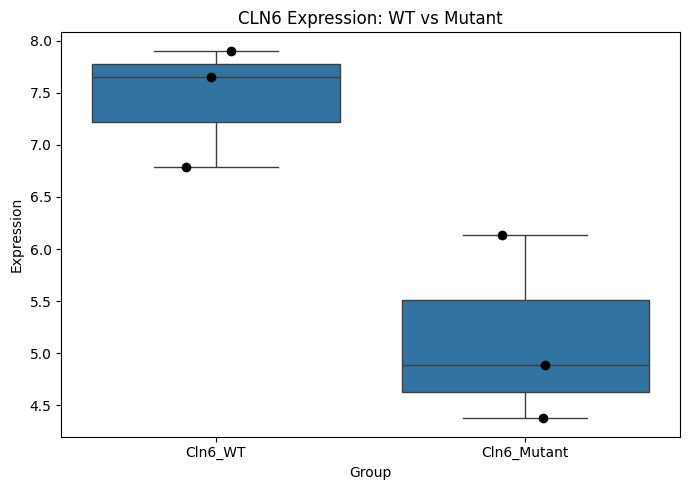

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=cln6_data,
    x="Group",
    y="Expression"
)

sns.stripplot(
    data=cln6_data,
    x="Group",
    y="Expression",
    color="black",
    size=7
)

plt.title("CLN6 Expression: WT vs Mutant")
plt.xlabel("Group")
plt.ylabel("Expression")
plt.tight_layout()

plt.show()

In [41]:
# Calculate mean expression for each group
group_means = cln6_data.groupby("Group")["Expression"].mean()

wt_mean = group_means["Cln6_WT"]
mut_mean = group_means["Cln6_Mutant"]

# Difference on the log2 expression scale
log2_difference = mut_mean - wt_mean

# Fold change on the original expression scale
fold_change = 2 ** log2_difference

print("WT mean:", wt_mean)
print("Mutant mean:", mut_mean)
print("Mean difference (log2):", log2_difference)
print("Fold change (Mutant / WT):", fold_change)

WT mean: 7.449905394000001
Mutant mean: 5.132081458999999
Mean difference (log2): -2.3178239350000016
Fold change (Mutant / WT): 0.20056976742007995


In [36]:
summary = cln6_data.groupby("Group")["Expression"].agg(
    ["count", "mean", "std", "min", "max"]
)

print(summary)

             count      mean       std       min       max
Group                                                     
Cln6_Mutant      3  5.132081  0.904476  4.375950  6.134067
Cln6_WT          3  7.449905  0.585381  6.789385  7.904487


In [37]:
import gzip

with gzip.open("GSE24368_series_matrix.txt.gz", "rt") as f:
    for line in f:
        if "process" in line.lower() or "value" in line.lower():
            print(line.strip())

!Series_summary	"Variant late-infantile (vLINCL) and juvenile neuronal ceroid lipofuscinosis (JNCL) share clinical and pathological features, including lysosomal accumulation of mitochondrial ATP synthase subunit c, but the unrelated CLN6 and CLN3 genes may initiate disease via similar or distinct cellular processes. To gain insight into the NCL pathways, we established murine wild-type and vLINCL CbCln6nclf cerebellar cells and compared them to wild-type and JNCL CbCln3∆ex7/8 cerebellar cells. CbCln6nclf/nclf cells and CbCln3∆ex7/8/∆ex7/8 cells both displayed abnormally elongated mitochondria and reduced cellular ATP levels and, as cells aged to confluence, exhibited accumulation of subunit c protein in Lamp 1-positive organelles. However, at sub-confluence, endoplasmic reticulum PDI immunostain was decreased only in CbCln6nclf/nclf cells, while fluid-phase endocytosis and LysoTracker labeled vesicles were decreased in both CbCln6nclf/nclf and CbCln3∆ex7/8/∆ex7/8 cells, though only th

In [38]:
from scipy.stats import ttest_ind

wt = cln6_data.loc[
    cln6_data["Group"] == "Cln6_WT",
    "Expression"
]

mut = cln6_data.loc[
    cln6_data["Group"] == "Cln6_Mutant",
    "Expression"
]

t_stat, p_value = ttest_ind(
    wt,
    mut,
    equal_var=False
)

print("Welch's t-statistic:", t_stat)
print("p-value:", p_value)

Welch's t-statistic: 3.7262504398952307
p-value: 0.02677610935766152


In [39]:
import numpy as np

wt_values = wt.to_numpy()
mut_values = mut.to_numpy()

pooled_sd = np.sqrt(
    (
        (len(wt_values) - 1) * np.var(wt_values, ddof=1)
        +
        (len(mut_values) - 1) * np.var(mut_values, ddof=1)
    )
    /
    (len(wt_values) + len(mut_values) - 2)
)

cohens_d = (wt_values.mean() - mut_values.mean()) / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: 3.042470743854891


In [40]:
# ==========================================
# Export final CLN6 results for Streamlit
# ==========================================

import pandas as pd

# 1. Export CLN6 expression data
cln6_data.to_csv("cln6_expression.csv", index=False)

# 2. Create a summary table
final_summary = pd.DataFrame({
    "Metric": [
        "Dataset",
        "Comparison",
        "WT samples",
        "Mutant samples",
        "WT mean expression",
        "Mutant mean expression",
        "Mean difference",
        "Percent change",
        "P-value",
        "Cohen's d"
    ],
    "Value": [
        "GSE24368",
        "Cln6_WT vs Cln6_Mutant",
        3,
        3,
        wt_mean,
        mut_mean,
        difference,
        percent_change,
        p_value,
        cohens_d
    ]
})

final_summary.to_csv("cln6_summary.csv", index=False)

print("Files exported successfully:")
print("- cln6_expression.csv")
print("- cln6_summary.csv")

Files exported successfully:
- cln6_expression.csv
- cln6_summary.csv


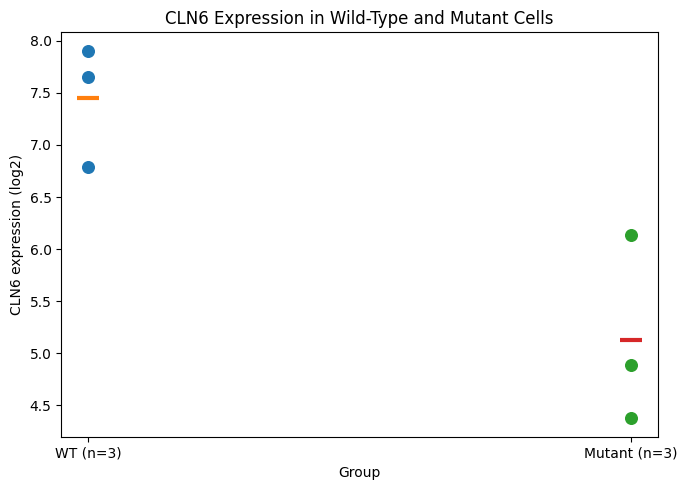

In [43]:
import matplotlib.pyplot as plt

groups = ["Cln6_WT", "Cln6_Mutant"]

plt.figure(figsize=(7, 5))

for i, group in enumerate(groups):
    values = cln6_data.loc[
        cln6_data["Group"] == group, "Expression"
    ].values

    # Individual samples
    plt.scatter(
        [i] * len(values),
        values,
        s=70
    )

    # Group mean
    mean_value = values.mean()

    plt.scatter(
        i,
        mean_value,
        marker="_",
        s=250,
        linewidths=3
    )

plt.xticks(
    [0, 1],
    ["WT (n=3)", "Mutant (n=3)"]
)

plt.ylabel("CLN6 expression (log2)")
plt.xlabel("Group")
plt.title("CLN6 Expression in Wild-Type and Mutant Cells")

plt.tight_layout()
plt.show()